# Signal Shape Analysis — Flu vs Dengue

This notebook asks a deeper question:

## Core question
How does the shape of a disease signal relate to its apparent predictability?

Instead of looking only at model scores, we quantify properties of the raw weekly time series such as:

- variability
- peakiness
- skewness
- kurtosis
- autocorrelation
- outbreak frequency

Then we compare these signal properties against the prediction-horizon results already obtained for flu and dengue.

## Goals
- compute signal-shape metrics for each disease
- summarize prediction-horizon behavior
- compare signal shape vs forecast behavior
- build a deeper explanation of why flu and dengue behaved differently

## Main idea
This notebook shifts the project from:
- "which disease is more predictable?"

to:
- "how does signal geometry affect predictability under a simple outbreak-classification framework?"

In [46]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import kurtosis, skew

sys.path.append(str(Path("..").resolve()))

from config import savefig, print_config_summary

print_config_summary()

===== CONFIG SUMMARY =====
Base Dir: /Users/suvo/Projects/disease-outbreak
Default Disease: flu
Default Region: illinois
Forecast Horizons: [1, 2, 3, 4]
Default Lags: [1, 2, 3, 4]
Default Outbreak Quantile: 0.85
Raw Data Dir: /Users/suvo/Projects/disease-outbreak/data/raw
Interim Data Dir: /Users/suvo/Projects/disease-outbreak/data/interim
Processed Data Dir: /Users/suvo/Projects/disease-outbreak/data/processed
Figures Dir: /Users/suvo/Projects/disease-outbreak/outputs/figures
Tables Dir: /Users/suvo/Projects/disease-outbreak/outputs/tables
Models Dir: /Users/suvo/Projects/disease-outbreak/outputs/models
Flu Raw JSON: /Users/suvo/Projects/disease-outbreak/data/raw/flu/fluview_il_201040_202652.json
Flu Weather Raw JSON: /Users/suvo/Projects/disease-outbreak/data/raw/flu/weather_openmeteo_springfield_il_2010-10-01_2026-04-10.json


In [47]:
flu_df = pd.read_parquet("../data/processed/flu/flu_weekly_merged.parquet").copy()
dengue_df = pd.read_parquet("../data/processed/dengue/dengue_weekly_merged.parquet").copy()

flu_df["week_start"] = pd.to_datetime(flu_df["week_start"])
dengue_df["week_start"] = pd.to_datetime(dengue_df["week_start"])

flu_df = flu_df.sort_values("week_start").reset_index(drop=True)
dengue_df = dengue_df.sort_values("week_start").reset_index(drop=True)

print("Flu shape:", flu_df.shape)
print("Dengue shape:", dengue_df.shape)

Flu shape: (808, 23)
Dengue shape: (261, 7)


In [48]:
flu_df = pd.read_parquet("../data/processed/flu/flu_weekly_merged.parquet").copy()
dengue_df = pd.read_parquet("../data/processed/dengue/dengue_weekly_merged.parquet").copy()

flu_results = pd.read_parquet("../outputs/tables/flu_results_df.parquet").copy()
dengue_results = pd.read_parquet("../outputs/tables/dengue_results_df.parquet").copy()

flu_df["week_start"] = pd.to_datetime(flu_df["week_start"])
dengue_df["week_start"] = pd.to_datetime(dengue_df["week_start"])

flu_df = flu_df.sort_values("week_start").reset_index(drop=True)
dengue_df = dengue_df.sort_values("week_start").reset_index(drop=True)

print("Flu signal shape:", flu_df.shape)
print("Dengue signal shape:", dengue_df.shape)
print("Flu results shape:", flu_results.shape)
print("Dengue results shape:", dengue_results.shape)

Flu signal shape: (808, 23)
Dengue signal shape: (261, 7)
Flu results shape: (4, 6)
Dengue results shape: (4, 6)


In [49]:
display(flu_df.head())
display(dengue_df.head())

display(flu_results)
display(dengue_results)

,release_date,region,issue,epiweek,lag,num_ili,num_patients,num_providers,num_age_0,num_age_1,...,num_age_5,wili,ili,week_start,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,shortwave_radiation_sum,outbreak
0,2017-10-24,il,201740,201040,365,505,39390,74,None,None,...,None,1.28205,1.28205,2010-10-03,25.566667,10.933333,0.0,20.766667,18.210000,0
1,2017-10-24,il,201740,201041,364,600,41354,76,None,None,...,None,1.45089,1.45089,2010-10-10,24.557143,9.700000,0.2,31.342857,17.417143,0
2,2017-10-24,il,201740,201042,363,644,41122,76,None,None,...,None,1.56607,1.56607,2010-10-17,22.314286,7.571429,0.0,16.700000,16.500000,0
3,2017-10-24,il,201740,201043,362,623,42741,79,None,None,...,None,1.45762,1.45762,2010-10-24,19.057143,6.557143,7.4,25.342857,12.132857,0
4,2017-10-24,il,201740,201044,361,625,41966,79,None,None,...,None,1.48930,1.48930,2010-10-31,11.928571,0.585714,0.0,14.271429,13.637143,0


,week_start,number,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,shortwave_radiation_sum
0,2014-01-05,436,27.520000,24.120000,15.5,15.240000,14.884000
1,2014-01-12,479,27.871429,23.828571,40.8,13.442857,17.071429
2,2014-01-19,401,27.300000,23.885714,5.9,20.642857,17.952857
3,2014-01-26,336,27.142857,23.214286,1.5,19.128571,19.302857
4,2014-02-02,234,28.271429,22.828571,0.7,19.042857,22.348571


,horizon_weeks,f1,precision,recall,n_train,n_test
0,1,0.777778,0.777778,0.777778,479,324
1,2,0.617284,0.675676,0.568182,479,323
2,3,0.500000,0.512195,0.488372,479,322
3,4,0.388889,0.466667,0.333333,479,321


,horizon_weeks,f1,precision,recall,n_train,n_test
0,1,0.875000,0.875000,0.875000,102,155
1,2,0.800000,0.750000,0.857143,102,154
2,3,0.769231,0.714286,0.833333,102,153
3,4,0.727273,0.666667,0.800000,102,152


Saved figure: /Users/suvo/Projects/disease-outbreak/outputs/figures/flu/signal_shape_flu_raw_series.png


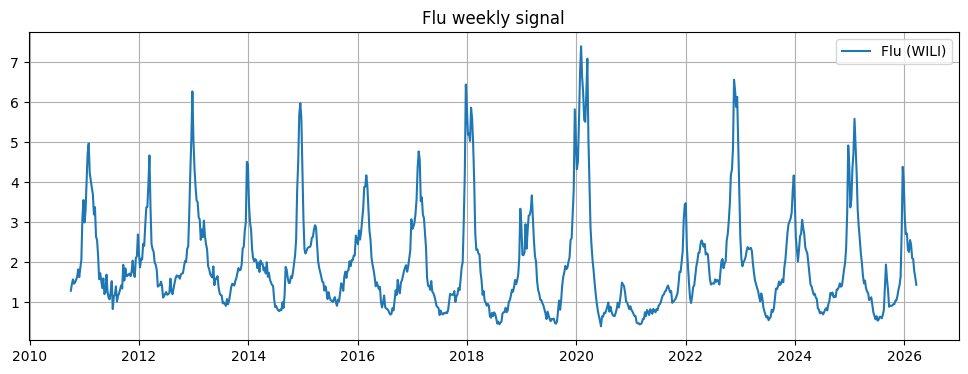

In [50]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(flu_df["week_start"], flu_df["wili"], label="Flu (WILI)")
ax.set_title("Flu weekly signal")
ax.legend()
ax.grid(True)

savefig(fig, "signal_shape_flu_raw_series.png", subdir="flu")
plt.show()

Saved figure: /Users/suvo/Projects/disease-outbreak/outputs/figures/dengue/signal_shape_dengue_raw_series.png


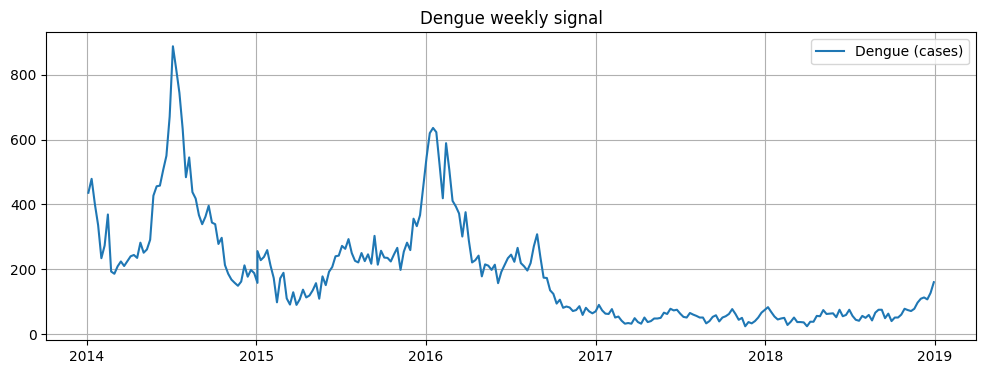

In [51]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dengue_df["week_start"], dengue_df["number"], label="Dengue (cases)")
ax.set_title("Dengue weekly signal")
ax.legend()
ax.grid(True)

savefig(fig, "signal_shape_dengue_raw_series.png", subdir="dengue")
plt.show()

Saved figure: /Users/suvo/Projects/disease-outbreak/outputs/figures/signal_shape_horizon_comparison.png


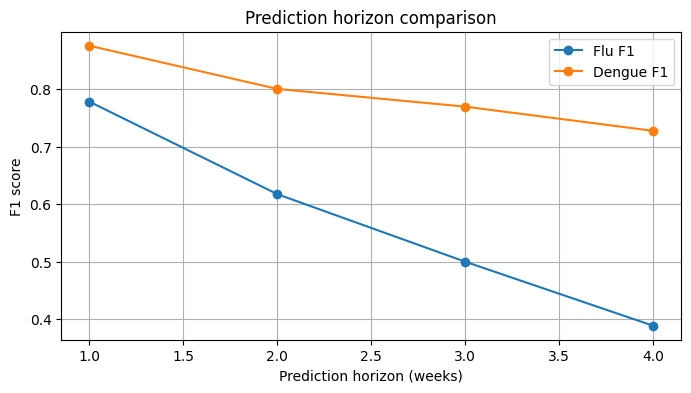

In [52]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(flu_results["horizon_weeks"], flu_results["f1"], marker="o", label="Flu F1")
ax.plot(dengue_results["horizon_weeks"], dengue_results["f1"], marker="o", label="Dengue F1")
ax.set_xlabel("Prediction horizon (weeks)")
ax.set_ylabel("F1 score")
ax.set_title("Prediction horizon comparison")
ax.legend()
ax.grid(True)

savefig(fig, "signal_shape_horizon_comparison.png")
plt.show()

In [53]:
def compute_signal_metrics(series: pd.Series, outbreak_quantile: float = 0.90) -> dict:
    s = series.dropna().astype(float).reset_index(drop=True)

    threshold = s.quantile(outbreak_quantile)
    outbreak = (s >= threshold).astype(int)
    diff = s.diff().dropna()

    peak_median_ratio = s.max() / s.median() if s.median() != 0 else np.nan
    peak_mean_ratio = s.max() / s.mean() if s.mean() != 0 else np.nan

    return {
        "n_points": len(s),
        "mean": s.mean(),
        "std": s.std(),
        "cv": s.std() / s.mean() if s.mean() != 0 else np.nan,
        "min": s.min(),
        "max": s.max(),
        "median": s.median(),
        "peak_median_ratio": peak_median_ratio,
        "peak_mean_ratio": peak_mean_ratio,
        "skewness": skew(s, bias=False),
        "kurtosis": kurtosis(s, fisher=False, bias=False),
        "outbreak_threshold": threshold,
        "outbreak_rate": outbreak.mean(),
        "diff_std": diff.std(),
        "diff_mean_abs": diff.abs().mean(),
        "acf_lag_1": s.autocorr(lag=1),
        "acf_lag_2": s.autocorr(lag=2),
        "acf_lag_3": s.autocorr(lag=3),
        "acf_lag_4": s.autocorr(lag=4),
    }

In [54]:
flu_metrics = compute_signal_metrics(flu_df["wili"], outbreak_quantile=0.90)
dengue_metrics = compute_signal_metrics(dengue_df["number"], outbreak_quantile=0.90)

signal_metrics_df = pd.DataFrame([
    {"disease": "flu", **flu_metrics},
    {"disease": "dengue", **dengue_metrics},
])

signal_metrics_df.T

,0,1
disease,flu,dengue
n_points,808,261
mean,1.91961,186.421456
std,1.236723,158.706595
cv,0.644257,0.851332
min,0.391549,24.0
max,7.402,888.0
median,1.56471,157.0
peak_median_ratio,4.730589,5.656051
peak_mean_ratio,3.855992,4.7634


In [55]:
def compute_horizon_summary(results_df: pd.DataFrame) -> dict:
    x = results_df["horizon_weeks"].values.astype(float)
    y = results_df["f1"].values.astype(float)

    slope = np.polyfit(x, y, 1)[0]
    auc = np.trapz(y, x)

    return {
        "f1_h1": y[0],
        "f1_h4": y[-1],
        "f1_drop_h1_to_h4": y[0] - y[-1],
        "f1_ratio_h4_to_h1": y[-1] / y[0] if y[0] != 0 else np.nan,
        "f1_decay_slope": slope,
        "f1_auc": auc,
    }

In [56]:
flu_horizon_summary = compute_horizon_summary(flu_results)
dengue_horizon_summary = compute_horizon_summary(dengue_results)

horizon_summary_df = pd.DataFrame([
    {"disease": "flu", **flu_horizon_summary},
    {"disease": "dengue", **dengue_horizon_summary},
])

horizon_summary_df.T

,0,1
disease,flu,dengue
f1_h1,0.777778,0.875
f1_h4,0.388889,0.727273
f1_drop_h1_to_h4,0.388889,0.147727
f1_ratio_h4_to_h1,0.5,0.831169
f1_decay_slope,-0.128395,-0.047395
f1_auc,1.700617,2.370367


In [57]:
comparison_df = signal_metrics_df.merge(horizon_summary_df, on="disease")
comparison_df.T

,0,1
disease,flu,dengue
n_points,808,261
mean,1.91961,186.421456
std,1.236723,158.706595
cv,0.644257,0.851332
min,0.391549,24.0
max,7.402,888.0
median,1.56471,157.0
peak_median_ratio,4.730589,5.656051
peak_mean_ratio,3.855992,4.7634


In [58]:
comparison_df[[
    "disease",
    "std",
    "cv",
    "peak_median_ratio",
    "peak_mean_ratio",
    "skewness",
    "kurtosis",
    "acf_lag_1",
    "acf_lag_4",
    "f1_h1",
    "f1_h4",
    "f1_drop_h1_to_h4",
    "f1_decay_slope",
    "f1_auc",
]]

,disease,std,cv,peak_median_ratio,peak_mean_ratio,skewness,kurtosis,acf_lag_1,acf_lag_4,f1_h1,f1_h4,f1_drop_h1_to_h4,f1_decay_slope,f1_auc
0,flu,1.236723,0.644257,4.730589,3.855992,1.610198,5.738161,0.953717,0.706460,0.777778,0.388889,0.388889,-0.128395,1.700617
1,dengue,158.706595,0.851332,5.656051,4.763400,1.532442,5.669994,0.961698,0.842918,0.875000,0.727273,0.147727,-0.047395,2.370367


Saved figure: /Users/suvo/Projects/disease-outbreak/outputs/figures/signal_shape_summary_bars.png


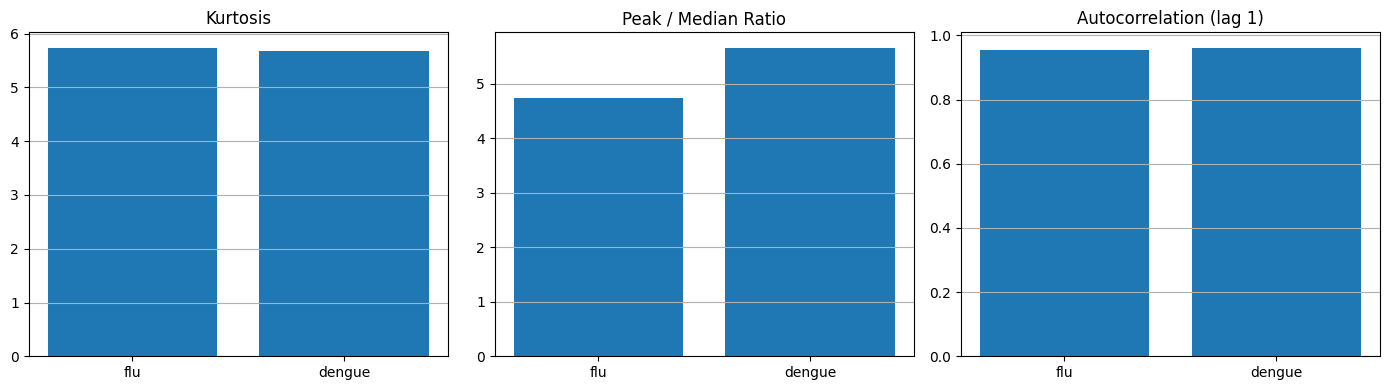

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(comparison_df["disease"], comparison_df["kurtosis"])
axes[0].set_title("Kurtosis")
axes[0].grid(True, axis="y")

axes[1].bar(comparison_df["disease"], comparison_df["peak_median_ratio"])
axes[1].set_title("Peak / Median Ratio")
axes[1].grid(True, axis="y")

axes[2].bar(comparison_df["disease"], comparison_df["acf_lag_1"])
axes[2].set_title("Autocorrelation (lag 1)")
axes[2].grid(True, axis="y")

plt.tight_layout()
savefig(fig, "signal_shape_summary_bars.png")
plt.show()

Saved figure: /Users/suvo/Projects/disease-outbreak/outputs/figures/signal_shape_predictability_bars.png


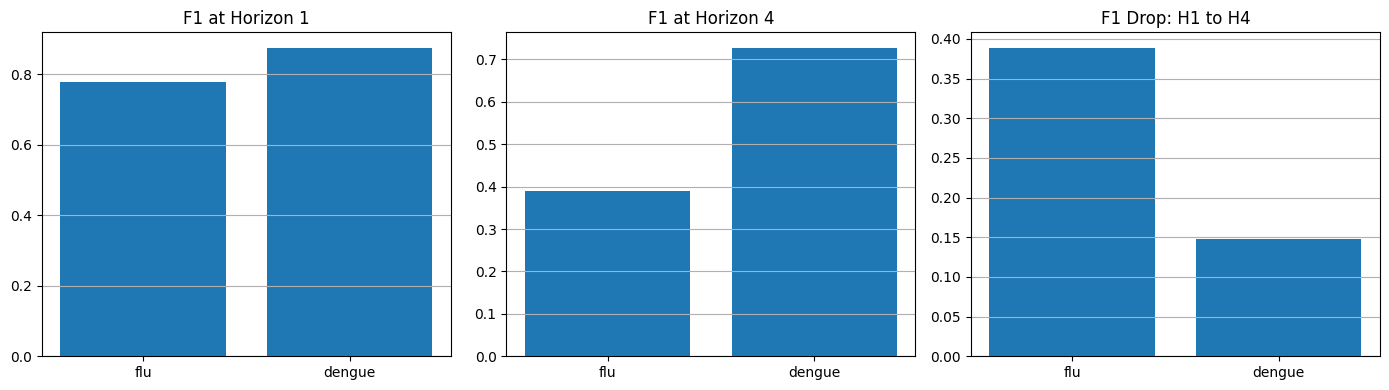

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(comparison_df["disease"], comparison_df["f1_h1"])
axes[0].set_title("F1 at Horizon 1")
axes[0].grid(True, axis="y")

axes[1].bar(comparison_df["disease"], comparison_df["f1_h4"])
axes[1].set_title("F1 at Horizon 4")
axes[1].grid(True, axis="y")

axes[2].bar(comparison_df["disease"], comparison_df["f1_drop_h1_to_h4"])
axes[2].set_title("F1 Drop: H1 to H4")
axes[2].grid(True, axis="y")

plt.tight_layout()
savefig(fig, "signal_shape_predictability_bars.png")
plt.show()

In [61]:
summary_lines = []

for _, row in comparison_df.iterrows():
    summary_lines.append(
        f"{row['disease'].title()}: "
        f"kurtosis={row['kurtosis']:.2f}, "
        f"peak/median={row['peak_median_ratio']:.2f}, "
        f"acf_lag1={row['acf_lag_1']:.2f}, "
        f"F1(H1)={row['f1_h1']:.2f}, "
        f"F1(H4)={row['f1_h4']:.2f}, "
        f"drop={row['f1_drop_h1_to_h4']:.2f}"
    )

print("\n".join(summary_lines))

Flu: kurtosis=5.74, peak/median=4.73, acf_lag1=0.95, F1(H1)=0.78, F1(H4)=0.39, drop=0.39
Dengue: kurtosis=5.67, peak/median=5.66, acf_lag1=0.96, F1(H1)=0.88, F1(H4)=0.73, drop=0.15


In [62]:
from pathlib import Path
from config import save_parquet, save_csv

save_parquet(comparison_df, Path("../outputs/tables/signal_shape_vs_predictability.parquet"))
save_csv(comparison_df, Path("../outputs/tables/signal_shape_vs_predictability.csv"))

comparison_df

Saved parquet: ../outputs/tables/signal_shape_vs_predictability.parquet
Saved csv: ../outputs/tables/signal_shape_vs_predictability.csv


,disease,n_points,mean,std,cv,min,max,median,peak_median_ratio,peak_mean_ratio,...,acf_lag_1,acf_lag_2,acf_lag_3,acf_lag_4,f1_h1,f1_h4,f1_drop_h1_to_h4,f1_ratio_h4_to_h1,f1_decay_slope,f1_auc
0,flu,808,1.919610,1.236723,0.644257,0.391549,7.402,1.56471,4.730589,3.855992,...,0.953717,0.875664,0.789584,0.706460,0.777778,0.388889,0.388889,0.500000,-0.128395,1.700617
1,dengue,261,186.421456,158.706595,0.851332,24.000000,888.000,157.00000,5.656051,4.763400,...,0.961698,0.925033,0.886623,0.842918,0.875000,0.727273,0.147727,0.831169,-0.047395,2.370367


In [63]:
def compute_event_metrics(series: pd.Series, outbreak_quantile: float = 0.90) -> dict:
    s = series.dropna().astype(float).reset_index(drop=True)

    threshold = s.quantile(outbreak_quantile)
    outbreak = (s >= threshold).astype(int)

    # --- Find contiguous outbreak segments ---
    segments = []
    in_segment = False
    start = 0

    for i, val in enumerate(outbreak):
        if val == 1 and not in_segment:
            in_segment = True
            start = i
        elif val == 0 and in_segment:
            segments.append((start, i - 1))
            in_segment = False

    if in_segment:
        segments.append((start, len(outbreak) - 1))

    # --- Metrics ---
    n_peaks = len(segments)

    # Peak widths (duration)
    peak_widths = [end - start + 1 for start, end in segments]
    avg_peak_width = np.mean(peak_widths) if peak_widths else np.nan

    # Peak spacing (distance between peaks)
    peak_centers = [(start + end) / 2 for start, end in segments]
    if len(peak_centers) > 1:
        peak_distances = np.diff(peak_centers)
        avg_peak_distance = np.mean(peak_distances)
    else:
        avg_peak_distance = np.nan

    # Fraction of time in outbreak
    outbreak_fraction = outbreak.mean()

    return {
        "n_peaks": n_peaks,
        "avg_peak_width": avg_peak_width,
        "avg_peak_distance": avg_peak_distance,
        "outbreak_fraction": outbreak_fraction,
    }

In [64]:
flu_event_metrics = compute_event_metrics(flu_df["wili"], outbreak_quantile=0.85)
dengue_event_metrics = compute_event_metrics(dengue_df["number"], outbreak_quantile=0.90)

event_metrics_df = pd.DataFrame([
    {"disease": "flu", **flu_event_metrics},
    {"disease": "dengue", **dengue_event_metrics},
])

event_metrics_df.T

,0,1
disease,flu,dengue
n_peaks,20,3
avg_peak_width,6.1,9.0
avg_peak_distance,41.236842,53.75
outbreak_fraction,0.15099,0.103448


In [65]:
comparison_df = (
    signal_metrics_df
    .merge(event_metrics_df, on="disease")
    .merge(horizon_summary_df, on="disease")
)

comparison_df.T

,0,1
disease,flu,dengue
n_points,808,261
mean,1.91961,186.421456
std,1.236723,158.706595
cv,0.644257,0.851332
min,0.391549,24.0
max,7.402,888.0
median,1.56471,157.0
peak_median_ratio,4.730589,5.656051
peak_mean_ratio,3.855992,4.7634


Saved figure: /Users/suvo/Projects/disease-outbreak/outputs/figures/signal_shape_event_structure.png


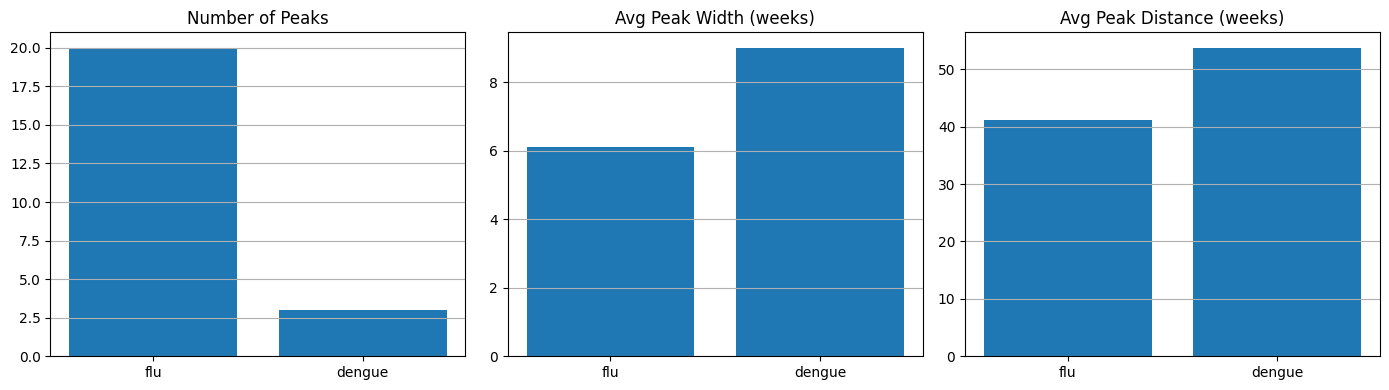

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(comparison_df["disease"], comparison_df["n_peaks"])
axes[0].set_title("Number of Peaks")
axes[0].grid(True, axis="y")

axes[1].bar(comparison_df["disease"], comparison_df["avg_peak_width"])
axes[1].set_title("Avg Peak Width (weeks)")
axes[1].grid(True, axis="y")

axes[2].bar(comparison_df["disease"], comparison_df["avg_peak_distance"])
axes[2].set_title("Avg Peak Distance (weeks)")
axes[2].grid(True, axis="y")

plt.tight_layout()
savefig(fig, "signal_shape_event_structure.png")
plt.show()

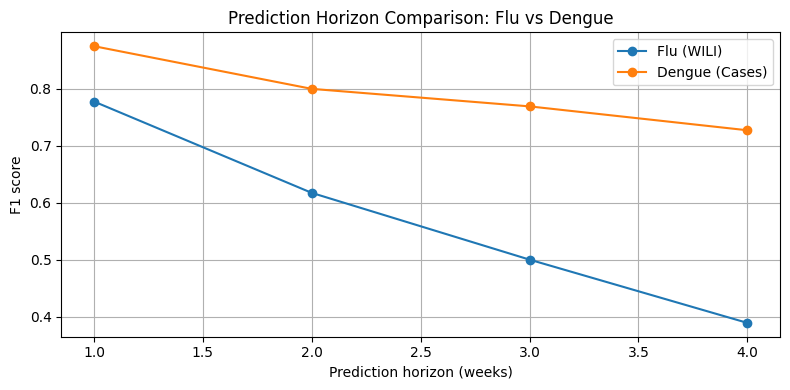

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

flu_results = pd.read_parquet("../outputs/tables/flu_results_df.parquet")
dengue_results = pd.read_parquet("../outputs/tables/dengue_results_df.parquet")

plt.figure(figsize=(8, 4))
plt.plot(flu_results["horizon_weeks"], flu_results["f1"], marker="o", label="Flu (WILI)")
plt.plot(dengue_results["horizon_weeks"], dengue_results["f1"], marker="o", label="Dengue (Cases)")

plt.xlabel("Prediction horizon (weeks)")
plt.ylabel("F1 score")
plt.title("Prediction Horizon Comparison: Flu vs Dengue")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("../outputs/figures/flu_vs_dengue_f1.png", dpi=300)
plt.show()